# **TSCAN** | **EfficientPhys** | **PhysFormer** - 1D Adaptations on POS Corpus

**Strategy**: All layers trainable from epoch 1. Backbone uses a lower learning rate than the regression head.

### What "fine-tuning" means here

The published models (TSCAN, EfficientPhys, PhysFormer) were designed for **facial video input** (3D spatiotemporal convolutions). Our data is **1D rPPG signals** from POS extraction, shape (`B, 1, 240)`.

*1D adaptations* are implemented here that mirror the temporal/attention design of each architecture. Pretrained weights from `open-rppg` are partially transferable:


| Layer type | Transferable? | Reason |
|---|---|---|
| 3D conv (Q, K projections) | **No** | Shape mismatch: `(3,3,3,96,96)` vs `(1,D,D)` |
| Linear V, proj `(96,96)` | **Yes** | Pure linear. Dimension-agnostic |
| LayerNorm / BN `(96,)` | **Yes** | 1D statistics. Shape-matched |
| CNN encoder (3D) | **No** | Video spatial dims don't transfer |

Expected transfer coverage: **~20-30%** of parameters - mainly the attention projection matrices and normalisation statistics.

### Comparison goal

After all three Optuna studies complete, compare:

```
  TSCAN_FT vs CRVSENet (subj MAE 2.37)
  EfficientPhys_FT vs CRVSEPhysFormer (subj MAE 2.06)
  PhysFormer_FT vs CRVSEResNetSE (r=0.9516)
```

## 1. Import and Configs

In [1]:
!pip install -q open-rppg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 MB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 91.9 MB/s eta 0:00:00


In [ ]:
import h5py, torch, os, optuna, pkg_resources, warnings
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR, SequentialLR
from torch.utils.data import Dataset, DataLoader
from optuna.pruners import MedianPruner
from optuna.samplers import TPESampler
from scipy import stats
from scipy.signal import resample
from collections import defaultdict
from tqdm import tqdm
from typing import Callable
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Fixed config - never tuned

H5_PATHS = {
    "ubfc_phys" : "/kaggle/input/datasets/cezarytubacki/rppg-pos-data/rPPG POS Data/ubfc_phys.h5",
    "ubfc_rppg" : "/kaggle/input/datasets/cezarytubacki/rppg-pos-data/rPPG POS Data/ubfc_rppg.h5",
    "ecg_fitness": "/kaggle/input/datasets/cezarytubacki/rppg-pos-data/rPPG POS Data/ecg_fitness.h5",
    "mcd_rppg" : "/kaggle/input/datasets/cezarytubacki/rppg-pos-data/rPPG POS Data/mcd_rppg.h5",
}

HR_MIN = 40.0
HR_MAX = 180.0 
MAX_NAN_FRAC = 0.10
TARGET_FRAMES = 240
WINDOW_SEC = 8
STRIDE_SEC = 4
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Tuning config
N_TRIALS = 50
N_EPOCHS = 50
BATCH_SIZE = 32
PRUNER_WARMUP = 5
WEIGHTS_DIR = pkg_resources.resource_filename("rppg", "weights")

print(f"Device: {DEVICE}")
print(f"Trials : {N_TRIALS} | Max epochs/trials {N_EPOCHS}")
print(f"Weights dir : {WEIGHTS_DIR}")

/tmp/ipykernel_22/3086137574.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import h5py, torch, os, optuna, pkg_resources, warnings


Device: cuda
Trials : 50 | Max epochs/trials 50
Weights dir : /usr/local/lib/python3.12/dist-packages/rppg/weights


## 2. Window extractor fuction

In [3]:
def extract_windows(rppg: np.ndarray, hr_cont: np.ndarray, fps: float, window_sec: int, stride_sec: int, target_frames: int, 
                    max_nan_frac: float, hr_min: float, hr_max: float) -> tuple[list[np.ndarray], list[float]]:
    """
    Extract sliding windows from one recording.

    Returns:
        windows : list of np.ndarray, each shape (target_frames,)
        labels : list of float, HR in BPM
    """
    window_frames = int(fps * window_sec)
    stride_frames = int(fps * stride_sec)
    n_frames = len(rppg)

    windows : list[np.ndarray] = []
    labels : list[float] = []

    for start in range(0, n_frames - window_frames + 1, stride_frames):
        end = start + window_frames

        rppg_win = rppg[start:end]
        hr_win = hr_cont[start:end]

        # NaN check on label
        nan_frac = np.sum(np.isnan(hr_win)) / len(hr_win)
        if nan_frac > max_nan_frac:
            continue
        
        # Compute scalar HR label
        hr_label = float(np.nanmean(hr_win))

        # Physiological sanity check
        if not (hr_min <= hr_label <= hr_max):
            continue

        # NaN check on signal
        if np.any(np.isnan(rppg_win)):
            continue

        # Resample to fixed length
        if len(rppg_win) != target_frames:
            rppg_win = resample(rppg_win, target_frames).astype(np.float32)

        # Z-score normalisation per window
        std = rppg_win.std()
        if std < 1e-6:
            continue
        rppg_win = (rppg_win - rppg_win.mean()) / std

        windows.append(rppg_win.astype(np.float32))
        labels.append(hr_label)

    return windows, labels

## 3. Index builder

In [4]:
def build_index(h5_paths : dict[str, str], window_sec: int, stride_sec: int, target_frames: int,
                max_nan_frac: float, hr_min: float, hr_max: float) -> tuple[list[dict], list[str]]:
    """
    Returns: 
        samples : list of dicts with keys: signal, hr_label, subject_key, dataset
        subject_keys : sorted list of unique subject identifiers (dataset + subject_id)
    """
    samples : list[dict] = []
    subject_keys : set[str] = set()

    for dataset_name, path in h5_paths.items():
        with h5py.File(path, "r") as file:
            subjects = file["subjects"]

            for subj_id in subjects.keys():
                subj_key = f"{dataset_name}__{subj_id}"
                subject_keys.add(subj_key)
                recordings = subjects[subj_id]["recordings"]

                for sess_id in recordings.keys():
                    rec = recordings[sess_id]
                    fps = float(rec.attrs["fps"])
                    rppg = rec["rppg_signal"][:]
                    hr = rec["hr_continuous"][:]

                    wins, labels = extract_windows(rppg, hr, fps, window_sec,
                                                stride_sec, target_frames,
                                                max_nan_frac, hr_min, hr_max)

                    for win, label in zip(wins, labels):
                        samples.append({
                            "signal" : win,
                            "hr_label" : label,
                            "subject_key" : subj_key,
                            "dataset" : dataset_name
                        })

    print(f"Total windows extracted : {len(samples)}")
    print(f"Total unique subjects : {len(subject_keys)}")
    return samples, sorted(subject_keys)

## 4. Subject-level train/val/test split

In [5]:
def subject_split(subject_keys: list[str], train_frac: float = 0.70,  val_frac: float = 0.15,seed : int = 42) -> tuple[set[str], set[str], set[str]]:
    """
    Returns three sets of subject_key strings.
    test_frac = 1 - train_frac - val_frac.
    """
    rng = np.random.default_rng(seed)
    keys = np.array(subject_keys)
    rng.shuffle(keys)

    n = len(keys)
    n_train = int(n * train_frac)
    n_val = int(n * val_frac)

    train_keys : set[str] = set(keys[:n_train])
    val_keys : set[str] = set(keys[n_train : n_train + n_val])
    test_keys : set[str] = set(keys[n_train + n_val :])

    print(f"Train subjects : {len(train_keys)}")
    print(f"Val subjects : {len(val_keys)}")
    print(f"Test subjects : {len(test_keys)}")
    return train_keys, val_keys, test_keys

## 5. Dataset class

In [6]:
class CRVSEDataset(Dataset):
    """
    PyTorch Dataset for CRVSE Phase 2 rPPG -> HR estimation.
    
    Args: 
        samples : list of dicts from build_index()
        subject_set : set of subject_key strings to include (train/val/test)
    """
    def __init__(self, samples: list[dict], subject_set: set[str]) -> None:
        self.items: list[dict] = [sample for sample in samples if sample["subject_key"] in subject_set]
        print(f"Dataset size: {len(self.items)} windows")

    def __len__(self) -> int:
        return len(self.items)

    def __getitem__(self, idx: int) -> tuple[torch.Tensor, torch.Tensor]:
        item = self.items[idx]
        signal = torch.tensor(item["signal"], dtype=torch.float32).unsqueeze(0)
        # shape: (1, TARGET_Framse) - (channels, time)
        label = torch.tensor(item["hr_label"], dtype=torch.float32)
        return signal, label 


def count_parameters(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

## 6. Fine-Tuning Architectures (1D Adaptations)

Three published rPPG architectures, each adapted to process 1D rPPG signals `(B, 1, 240)`:


| Architecture | Original input | 1D adaptation key change |
|---|---|---|
| **TSCAN_FT** | Video diff frames `(T, H, W, 3)` | 2D spatial conv -> 1D temporal conv, difference signal is rPPG diff |
| **EfficientPhys_FT** | Video frames `(T, H, W, 3)` | TSCAN + self-attention, 2D -> 1D, temporal shift preserved |
| **PhysFormer_FT** | Video patches `(T, H, W, 3)` | 3D conv -> 1D conv, TDT (Temporal Difference Transformer) preserved |


**Weight transfer from open-rppg pretrained `.h5` files** is attempted for each.
Coverage is ~20–30%: only shape-matched linear layers transfer (V/proj matrices, norm statistics).
The CNN encoders (3D→1D) do not transfer and receive Kaiming initialisation.

### Shared Module: Temporal Shift Module (1D)

TSM is the key innovation in TSCAN / EfficientPhys.
Shifts a fraction of channels backward/forward in time, giving the model a sence of temporal context without extra parameters.
Original: applied across video frames. Here: applied across signal timesteps.

In [7]:
class TSM1D(nn.Module):
    """
    Temporal Shift Module - 1D signal version.
    
    Shifts fold_div_th of channels backward (use past timestep) and another 
    fold_div_th forward (use future timestep), leaving the rest unchanged.
    Zero-cost temporal ocntext expansion.
    
    Args:
        n_channels : umber of feature channels (C)
        fold_div : 1/fold_div of channels are shifted each direction
    """
    def __init__(self, n_channels: int, fold_div: int) -> None:
        super().__init__()
        self.fold = max(1, n_channels // fold_div)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, C, T)
        B, C, T = x.shape
        fold = self.fold
        out = x.clone()
        # Shift first fold channels backward (past -> current)
        out[:, :fold, 1:] = x[:, :fold, :-1]
        out[:, :fold, :1] = x[:, :fold, :1] # pad boundary
        # Shift second fold channels forward (future -> current)
        out[:, fold:2*fold, :-1] = x[:, fold:2*fold, 1:]
        out[:, fold:2*fold, -1:] = x[:, fold:2*fold, -1:] # pad boundary
        return out

### Model : TSCAN_FT

In [8]:
class TSCAN_FT(nn.Module):
    """
    1D adaptation of TSCAN (Temporal Shift Convolutional Attention Network).

    Original two-stream design:
        Appearance stream : processes raw frames
        Motion stream : processes difference frames
        Cross-attention : appearance weights gate motion output

    1D adaptation:
        Appearance stream : processes rPPG signal x
        Motion stream : processes diff signal  Δx[t] = x[t] − x[t−1]
        Temporal Shift : applied to appearance features (TSM)
        Cross-attention : appearance-derived sigmoid weights gate motion

    Pretrained weight transfer:
        Attention linear (if base_channels=64 matches pretrained)
        LayerNorm/BN     (1D statistics, shape-matched)
    Skiped:
        CNN blocks (2D -> 1D shape mismatch)
    """
    def __init__(self, in_channels: int = 1, base_channels: int = 64, dropout: float = 0.2,
                 hr_min: float = 40.0, hr_max: float = 180.0) -> None:
        super().__init__()
        self.hr_min = hr_min
        self.hr_max = hr_max
        C = base_channels

        # Appearance stream 
        self.appearance = nn.Sequential(
            nn.Conv1d(in_channels, C // 2, kernel_size=3, padding=1),
            nn.BatchNorm1d(C // 2), nn.Tanh(),
            nn.Conv1d(C // 2, C, kernel_size=3, padding=1),
            nn.BatchNorm1d(C), nn.Tanh(),
            nn.Conv1d(C, C, kernel_size=3, padding=1),
            nn.BatchNorm1d(C), nn.Tanh(),
        )

        # Temporal Shift Module
        self.tsm = TSM1D(C, fold_div=8)

        # Attention head
        self.attention = nn.Sequential(nn.Conv1d(C, C, kernel_size=1), nn.BatchNorm1d(C), nn.Sigmoid())

        # Motion (difference) stream 
        self.motion = nn.Sequential(
            nn.Conv1d(in_channels, C // 2, kernel_size=3, padding=1),
            nn.BatchNorm1d(C // 2), nn.Tanh(),
            nn.Conv1d(C // 2, C, kernel_size=3, padding=1),
            nn.BatchNorm1d(C), nn.Tanh(),
            nn.Conv1d(C, C, kernel_size=3, padding=1),  
            nn.BatchNorm1d(C), nn.Tanh(), 
        )

        self.dropout = nn.Dropout(dropout)

        # Regression head
        self.head = nn.Sequential(nn.Linear(C, 32), nn.ELU(), nn.Dropout(dropout), nn.Linear(32, 1))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, 1, T)
        # Compute difference signal (motion analog)
        diff = torch.zeros_like(x)
        diff[:, :, 1:] = x[:, :, 1:] - x[:, :, :-1]

        # Appearance stream -> TSM -> attention weights
        app = self.appearance(x) # (B, C, T)
        app = self.tsm(app) # temporal shift
        weights = self.attention(app) # (B, C, T)  ∈ [0,1]

        # Motion stream gated by appearance attention
        mot = self.motion(diff) # (B, C, T)
        out = mot * weights # element-wise gating
        out = self.dropout(out)

        out = out.mean(dim=-1) # (B, C)  global avg pool
        out = self.head(out).squeeze(-1) # (B,)

        if not self.training:
            out = out.clamp(self.hr_min, self.hr_max)
        return out


### Model: EfficientPhys_FT

In [9]:
class EfficientPhys_FT(nn.Module):
    """
    1D adaptation of EfficientPhys (Efficient Self-Attention TSCAN).

    Key change vs TSCAN: replaces cross-stream attention with
    self-attention on the temporally-shifted features.
    More parameter-efficient. Captures long-range temporal dependencies
    within a single stream.

    1D adaptation:
        CNN encoder : extracts local pulse features from rPPG signal
        TSM : zero-cost temporal context expansion
        Self-attention : multi-head attention along time axis
        FFN : position-wise feed-forward

    Pretrained weight transfer:
        Self-attn Q/K/V (linear, if base_channels matches d_model)
        FFN linear layers (shape-matched)
        LayerNorm  (shape-matched)
    Skiped:
        CNN blocks (2D->1D)
    """
    def __init__(self, in_channels: int  = 1, base_channels: int = 64, n_heads: int = 4, dropout: float = 0.2, 
                 hr_min: float = 40.0, hr_max: float = 180.0) -> None:
        super().__init__()
        assert base_channels % n_heads == 0, "base_channels must be divisible by n_heads"
        self.hr_min = hr_min
        self.hr_max = hr_max
        C = base_channels

        # CNN encoder 
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, C // 2, kernel_size=3, padding=1),
            nn.BatchNorm1d(C // 2), nn.ELU(), nn.Dropout(dropout),
            nn.Conv1d(C // 2, C, kernel_size=3, padding=1),
            nn.BatchNorm1d(C), nn.ELU(), nn.Dropout(dropout),
            nn.Conv1d(C, C, kernel_size=3, padding=1),
            nn.BatchNorm1d(C), nn.ELU(),
        )

        # Temporal Shift
        self.tsm = TSM1D(C, fold_div=8)

        # Self-Attention block (pre-norm) 
        self.norm1 = nn.LayerNorm(C)
        self.self_attn = nn.MultiheadAttention(embed_dim=C, num_heads=n_heads, dropout=dropout, batch_first=True)

        # Feed-Forward block (pre-norm)
        self.norm2 = nn.LayerNorm(C)
        self.ffn = nn.Sequential(nn.Linear(C, C * 4), nn.GELU(), nn.Dropout(dropout), nn.Linear(C * 4, C))

        self.dropout = nn.Dropout(dropout)

        # Regression head
        self.head = nn.Sequential(nn.Linear(C, 32), nn.ELU(), nn.Dropout(dropout), nn.Linear(32, 1))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, 1, T)
        out = self.encoder(x) # (B, C, T)
        out = self.tsm(out) # temporal shift

        out = out.permute(0, 2, 1) # (B, T, C)

        # Self-attention with residual (pre-norm)
        res = out
        out = self.norm1(out)
        attn_out, _ = self.self_attn(out, out, out)
        out = res + self.dropout(attn_out)

        # FFN with residual (pre-norm)
        res = out
        out = self.ffn(self.norm2(out))
        out = res + self.dropout(out)

        out = out.mean(dim=1) # (B, C)  global avg pool over time
        out = self.head(out).squeeze(-1) # (B,)

        if not self.training:
            out = out.clamp(self.hr_min, self.hr_max)
        return out

### Model: PhysFormer_FT

In [10]:
class TemporalDifferenceLayer(nn.Module):
    """
    Temporal Difference Layer - PhysFormer's core innovation.

    At each position, augments the feature with its first-order temporal
    difference: f_td[t] = f[t] + (f[t] - f[t-1]).
    Sharpens quasi-periodic pulse patterns; directly analogous to rPPG
    signal differentiation that enhances peak-to-peak contrast.
    """
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: (B, T, C)
        diff = torch.zeros_like(x)
        diff[:, 1:, :] = x[:, 1:, :] - x[:, :-1, :]
        return x + diff


class PhysFormer_FT(nn.Module):
    """
    1D adaptation of PhysFormer (Temporal Difference Transformer).

    Why PhysFormer wins vs vanilla Transformer (confirmed in our Round 3):
    The frequency supervision head acts as an anchor — it penalises the
    model for attending to non-physiological frequencies, preventing the
    systematic HR overestimation seen in CRVSETransformer and LocalAttention.

    1D adaptation:
        CNN encoder : extracts local pulse features (1D)
        Frequency branch : FFT magnitude -> compact freq descriptor
        Temporal Difference : applied before each transformer layer
        Transformer : standard multi-head self-attention (pre-norm)
        Frequency head : auxiliary regression from freq features (training only)

    Pretrained weight transfer:
        V projection (linear (96,96) -> transferable if d_model=96)
        Out projection (linear (96,96))
        FFN linear layers
        LayerNorm statistics
        Transfer coverage ~ 25–35%

    Skiped:
        CNN encoder (3D->1D)
        Q, K projections (original uses CDC, a 3D centre-difference conv)

    Training loss:
        L = L_HR_main + lambda_freq × L_HR_freq
        lambda_freq anneals from 1.0 → 0.0 over training
        (forces the model to use frequency information early, then relaxes)
    """
    def __init__(self, in_channels: int = 1, cnn_channels: int = 64, freq_channels: int = 32, n_heads: int = 4, n_layers: int = 2,
                 dim_feedforward: int = 256, dropout: float = 0.2, hr_min: float = 40.0, hr_max: float = 180.0) -> None:
        super().__init__()
        # d_model = cnn_channels + freq_channels, snapped to n_heads divisibility
        d_model = cnn_channels + freq_channels
        d_model = (d_model // n_heads) * n_heads
        freq_channels = d_model - cnn_channels # recompute after snap

        self.hr_min = hr_min
        self.hr_max = hr_max
        self.d_model = d_model
        self.cnn_channels = cnn_channels
        self.freq_channels = freq_channels

        # CNN temporal encoder 
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, cnn_channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(cnn_channels), nn.ELU(), nn.Dropout(dropout),
            nn.Conv1d(cnn_channels, cnn_channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(cnn_channels), nn.ELU(), nn.Dropout(dropout),
            nn.Conv1d(cnn_channels, cnn_channels, kernel_size=3, padding=1),
            nn.BatchNorm1d(cnn_channels), nn.ELU(),
        )

        # Frequency branch
        # FFT magnitude -> compact representation of dominant frequency
        n_fft = TARGET_FRAMES // 2 + 1 # 121 for T=240
        self.freq_encoder = nn.Sequential(
            nn.Linear(n_fft, freq_channels * 2), nn.ELU(), 
            nn.Linear(freq_channels * 2, freq_channels), nn.ELU())

        # Input projection to d_model 
        self.input_proj = nn.Linear(cnn_channels + freq_channels, d_model)

        # Temporal Difference Layer 
        self.td_layer = TemporalDifferenceLayer()

        # Transformer encoder (pre-norm)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
            norm_first=True, # Pre-norm — more stable on small datasets
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)

        # Main HR regression head 
        self.head = nn.Sequential(nn.Linear(d_model, 64), nn.ELU(), nn.Dropout(dropout), nn.Linear(64, 1))

        # Frequency supervision head 
        # Auxiliary head predicting HR from frequency features only.
        # Active during training - anchors the model to physiological frequencies.
        # Prevents the systematic overestimation seen in CRVSETransformer.
        self.freq_head = nn.Sequential(nn.Linear(freq_channels, 32), nn.ELU(), nn.Linear(32, 1))

    def forward(self, x: torch.Tensor) -> tuple | torch.Tensor:
        # x: (B, 1, T)
        B, _, T = x.shape

        # CNN temporal features
        cnn_out = self.encoder(x) # (B, cnn_C, T)

        # Frequency features (global: one vector per window)
        fft_mag = torch.abs(torch.fft.rfft(x.squeeze(1), dim=-1)) # (B, T//2+1)
        freq_feat = self.freq_encoder(fft_mag) # (B, freq_C)
        freq_exp = freq_feat.unsqueeze(2).expand(-1, -1, T) # (B, freq_C, T)

        # Combine and project
        combined = torch.cat([cnn_out, freq_exp], dim=1) # (B, cnn+freq, T)
        combined = combined.permute(0, 2, 1) # (B, T, C)
        combined = self.input_proj(combined) # (B, T, d_model)

        # Temporal difference -> transformer
        combined = self.td_layer(combined) # sharpens pulse
        out = self.transformer(combined) # (B, T, d_model)
        out = out.mean(dim=1) # (B, d_model)

        hr_main = self.head(out).squeeze(-1) # (B,)
        hr_freq = self.freq_head(freq_feat).squeeze(-1) # (B,) auxiliary

        if not self.training:
            return hr_main.clamp(self.hr_min, self.hr_max)

        return hr_main, hr_freq   # training returns both for combined loss


In [11]:

# Models sanity check
dummy = torch.randn(4, 1, TARGET_FRAMES)
print("Architecture sanity check")
print("─" * 50)

for name, cls, kwargs in [
    ("TSCAN_FT", TSCAN_FT, dict(base_channels=128)),
    ("EfficientPhys_FT",EfficientPhys_FT,dict(base_channels=64, n_heads=4)),
    ("PhysFormer_FT", PhysFormer_FT, dict(cnn_channels=64, freq_channels=32, n_heads=4, n_layers=2, dim_feedforward=256)),
]:
    model = cls(**kwargs, hr_min=HR_MIN, hr_max=HR_MAX)
    model.eval()
    with torch.no_grad():
        out = model(dummy)
    if isinstance(out, tuple):
        out = out[0]
    print(f"{name:<22} | params: {count_parameters(model):>8,} | output: {tuple(out.shape)}")

Architecture sanity check
──────────────────────────────────────────────────
TSCAN_FT               | params:  170,689 | output: (4,)
EfficientPhys_FT       | params:   71,105 | output: (4,)
PhysFormer_FT          | params:  234,626 | output: (4,)


## 7. Pretrained Weight Loader


In [12]:
def load_pretrained_partial(model: nn.Module, h5_path: str, verbose: bool = True) -> float:
    """
    Load pretrained weights from an open-rppg HDF5 file into a PyTorch model.

    Strategy: shape-based matching.
      1. Collect all tensors from the h5 file, grouped by shape.
      2. For each PyTorch parameter, if exactly one h5 tensor has the same shape,
         load it.
      3. Skip ambiguous (multiple candidates) or unmatched shapes.
      4. Return the fraction of parameters successfully loaded.

    Returns:
        transfer_frac : float - fraction of total parameters loaded from pretrained
    """
    if not os.path.exists(h5_path):
        if verbose:
            print(f"Weight file not found: {h5_path}")
            print(f"Random initialisation (Kaiming)")
        return 0.0

    # Collect all h5 tensors grouped by shape
    shape_to_arrays = defaultdict(list)
    with h5py.File(h5_path, "r") as file:
        def collect(name, obj):
            if hasattr(obj, "shape") and len(obj.shape) >= 1:
                arr = np.array(obj, dtype=np.float32)
                shape_to_arrays[arr.shape].append(arr)
        file.visititems(collect)

    # Match PyTorch params by shape 
    own_sd = model.state_dict()
    new_sd = {}
    matched = 0
    total = sum(p.numel() for p in own_sd.values())
    shape_used = defaultdict(int)  # track which shapes were consumed

    for name, param in own_sd.items():
        shape = tuple(param.shape)
        candidates = shape_to_arrays.get(shape, [])
        idx = shape_used[shape]

        if idx < len(candidates):
            # Load the next unused tensor with this shape
            new_sd[name] = torch.from_numpy(candidates[idx])
            shape_used[shape] += 1
            matched += param.numel()
        else:
            new_sd[name] = param  # keep random init

    model.load_state_dict(new_sd)
    frac = matched / total if total > 0 else 0.0

    if verbose:
        print(f"Pretrained transfer: {matched:,} / {total:,} params = {frac*100:.1f}%")

    return frac


# Registry: maps model name > (class, fixed_kwargs, h5_filename)
# Architecture kwargs are FIXED here — these are not tuned in Optuna.
# Only training hyperparameters are searched.
ARCH_REGISTRY: dict[str, dict] = {
    "TSCAN_FT": {
        "cls"    : TSCAN_FT,
        "kwargs" : dict(base_channels=128),
        "h5"     : "TSCAN.pure.weights.h5",
    },
    "EfficientPhys_FT": {
        "cls"    : EfficientPhys_FT,
        "kwargs" : dict(base_channels=64, n_heads=4),
        "h5"     : "EfficientPhys.pure.weights.h5",
    },
    "PhysFormer_FT": {
        "cls"    : PhysFormer_FT,
        "kwargs" : dict(cnn_channels=64, freq_channels=32, n_heads=4, n_layers=2, dim_feedforward=256),
        "h5"     : "PhysFormer.pure.weights.h5",
    },
}

# Dry run - check what each model transfers
print("Pretrained weight transfer report")
print("─" * 55)
for arch_name, cfg in ARCH_REGISTRY.items():
    model = cfg["cls"](**cfg["kwargs"], dropout=0.2, hr_min=HR_MIN, hr_max=HR_MAX)
    h5_path = os.path.join(WEIGHTS_DIR, cfg["h5"])
    print(f"\n{arch_name}")
    frac = load_pretrained_partial(model, h5_path, verbose=True)
    n_total = count_parameters(model)
    print(f"Total params : {n_total:,}")
    print(f"Random init : {int(n_total * (1 - frac)):,}")


Pretrained weight transfer report
───────────────────────────────────────────────────────

TSCAN_FT
Pretrained transfer: 417 / 172,232 params = 0.2%
Total params : 170,689
Random init : 170,275

EfficientPhys_FT
Pretrained transfer: 289 / 71,428 params = 0.4%
Total params : 71,105
Random init : 70,817

PhysFormer_FT
Pretrained transfer: 28,897 / 235,013 params = 12.3%
Total params : 234,626
Random init : 205,776


## 8. Freeze / Unfreeze functions


In [13]:
def get_param_groups(model: nn.Module, lr_backbone: float, lr_head: float) -> list:
    """
    Split model into two parameter group:
    backbone_params : all parameters EXCEPT the final head
    head_params : parameters in model.head
    
    Returns an AdamW-compatible param_groups list.
    Fine-tuning rule: lr_backbone << lr_head (typically 10x difference)
    """
    head_ids = {id(p) for p in model.head.parameters()}
    backbone = [p for p in model.parameters() if id(p) not in head_ids]
    head = [p for p in model.parameters() if id(p) in head_ids]
    return [
        {"params" : backbone, "lr" : lr_backbone, "name" : "backbone"},
        {"params" : head, "lr" : lr_head, "name" : "head"}
    ]


def freeze_module(module: nn.Module) -> None:
    """Freeze all parameters in a module."""
    for p in module.parameters():
        p.requires_grad = False


def unfreeze_module(module: nn.Module) -> None:
    """Unfreeze all parameters in a module."""
    for p in module.parameters():
        p.requires_grad = True


def param_group_summary(optimizer: torch.optim.Optimizer) -> None:
    """Print current LR for each param group."""
    for g in optimizer.param_groups:
        name = g.get("name", "unnamed")
        n = sum(p.numel() for p in g["params"])
        print(f"Group '{name}': lr={g['lr']:.2e} params{n:,}")
        

## 9. Evaluation Functions

In [14]:
def compute_subject_level_metrics(preds: np.ndarray, labels: np.ndarray, subject_ids: list) -> dict:
    subj_preds = defaultdict(list)
    subj_labels = defaultdict(list)
    for p, l, s in zip(preds, labels, subject_ids):
        subj_preds[s].append(p)
        subj_labels[s].append(l)

    subj_pred_mean = np.array([np.mean(v) for v in subj_preds.values()])
    subj_label_mean = np.array([np.mean(v) for v in subj_labels.values()])
    diff = subj_pred_mean - subj_label_mean
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff ** 2)))
    r, _ = stats.pearsonr(subj_pred_mean, subj_label_mean)
    ba_bias = float(diff.mean())
    ba_sd  = float(diff.std())
    print(f"\nSubject-level metrics (n={len(subj_pred_mean)} subjects):")
    print(f"MAE : {mae:.2f} BPM")
    print(f"RMSE : {rmse:.2f} BPM")
    print(f"r : {r:.4f}")
    print(f"BA bias: {ba_bias:.2f}  LoA: [{ba_bias-1.96*ba_sd:.2f}, {ba_bias+1.96*ba_sd:.2f}] BPM")
    return {"subj_mae": mae, "subj_rmse": rmse, "subj_r": r,
            "ba_bias": ba_bias, "ba_loa_lo": ba_bias-1.96*ba_sd,
            "ba_loa_hi": ba_bias+1.96*ba_sd, "n_subjects": len(subj_pred_mean)}


def coverage_metrics(preds: np.ndarray, labels: np.ndarray) -> None:
    abs_err = np.abs(preds - labels)
    for thr in [5, 10, 15]:
        print(f"|error| < {thr:>2} BPM : {np.mean(abs_err < thr)*100:.1f}%")


def per_dataset_metrics(preds: np.ndarray, labels: np.ndarray, dataset_ids: list[str]) -> None:
    print("\nPer-dataset breakdown:")
    print(f"{'Dataset':<15} {'n':>5} {'MAE':>8} {'RMSE':>8} {'r':>8}")
    print(f"{'-'*46}")
    for ds in sorted(set(dataset_ids)):
        mask = np.array([d == ds for d in dataset_ids])
        p, l = preds[mask], labels[mask]
        if len(p) < 2: continue
        r, _ = stats.pearsonr(p, l)
        print(f"  {ds:<15} {len(p):>5} {np.mean(np.abs(p-l)):>8.2f} "
              f"{np.sqrt(np.mean((p-l)**2)):>8.2f} {r:>8.4f}")


def hr_stratified_metrics(preds: np.ndarray, labels: np.ndarray) -> None:
    bins = [(40,65,"bradycardia/low"),(65,85,"normal low"), (85,100,"normal high"),(100,180,"tachycardia/exercise")]
    print("\nHR-stratified metrics:")
    print(f"{'Range':<22} {'n':>5} {'MAE':>8} {'RMSE':>8}")
    print(f"{'-'*46}")
    for lo, hi, label in bins:
        mask = (labels >= lo) & (labels < hi)
        if mask.sum() < 2: continue
        p, l = preds[mask], labels[mask]
        print(f"{label:<22} {mask.sum():>5} {np.mean(np.abs(p-l)):>8.2f} "
              f"{np.sqrt(np.mean((p-l)**2)):>8.2f}")


def full_evaluation(preds: np.ndarray, labels: np.ndarray, subject_ids: list, dataset_ids: list, model_name: str = "Model") -> dict:
    print(f"\n{'='*55}")
    print(f"FULL EVALUATION - {model_name}")
    print(f"{'='*55}")
    diff = preds - labels
    mae = float(np.mean(np.abs(diff)))
    rmse = float(np.sqrt(np.mean(diff**2)))
    mape = float(np.mean(np.abs(diff) / np.abs(labels)) * 100)
    r, pval = stats.pearsonr(preds, labels)
    r2 = float(1 - np.sum(diff**2) / np.sum((labels - labels.mean())**2))
    ba_bias = float(diff.mean())
    ba_sd = float(diff.std())
    loa_lo = ba_bias - 1.96*ba_sd
    loa_hi = ba_bias + 1.96*ba_sd
    print(f"\nWindow-level (n={len(preds)} windows):")
    print(f"MAE : {mae:.2f} BPM")
    print(f"RMSE : {rmse:.2f} BPM")
    print(f"MAPE : {mape:.2f} %")
    print(f"Pearson r : {r:.4f} (p={pval:.4f})")
    print(f"R² : {r2:.4f}")
    print(f"BA bias : {ba_bias:.2f} LoA: [{loa_lo:.2f}, {loa_hi:.2f}] BPM")
    print()
    coverage_metrics(preds, labels)
    subj_metrics = compute_subject_level_metrics(preds, labels, subject_ids)
    per_dataset_metrics(preds, labels, dataset_ids)
    hr_stratified_metrics(preds, labels)
    return {"window_mae": mae, "window_rmse": rmse, "window_r": r,
            "r2": r2, "ba_bias": ba_bias, "loa_lo": loa_lo, "loa_hi": loa_hi,
            **subj_metrics}


## 10. Data Preparation

In [15]:
all_samples, all_subject_keys = build_index(H5_PATHS, WINDOW_SEC, STRIDE_SEC, TARGET_FRAMES, MAX_NAN_FRAC, HR_MIN, HR_MAX)

train_keys, val_keys, test_keys = subject_split(all_subject_keys, train_frac=0.70, val_frac = 0.15, seed=SEED)

print(f"\nTrain dataset:")
train_ds = CRVSEDataset(all_samples, train_keys)
print("Val dataset:")
val_ds = CRVSEDataset(all_samples, val_keys)
print("Test dataset:")
test_ds = CRVSEDataset(all_samples, test_keys)

# Fixed loaders - reused by every trial
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count(), pin_memory=True)

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)

test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=os.cpu_count(), pin_memory=True)

Total windows extracted : 9501
Total unique subjects : 194
Train subjects : 135
Val subjects : 29
Test subjects : 30

Train dataset:
Dataset size: 6656 windows
Val dataset:
Dataset size: 1421 windows
Test dataset:
Dataset size: 1424 windows


## 11. Architecture-Transfer Optuna Studies

After inspecting the open-rppg pretrained weights, the transfer coverage is:

| Model | Pretrained transfer | Reality |
|---|---|---|
| **TSCAN_FT** | ~0.2% | Architecture-inspired, trained from scratch |
| **EfficientPhys_FT** | ~0.4% | Architecture-inspired, trained from scratch |
| **PhysFormer_FT** | ~12.3% | Linear projection matrices transferred, 88% random |

The open-rppg weights are JAX-based with 3D spatiotemporal convolutions. 1D signal pipeline has near-zero shape overlap with those conv layers. So here **architectural design transfer** is compared, not weight transfer.

### Optuna search space

Architecture hyperparameters are **fixed** - only training dynamics are searched:

| Hyperparameter | Range | Rationale |
|---|---|---|
| `lr_head` | 1e-4 to 5e-4 | Head randomly initialised - needs higher LR |
| `lr_backbone` | 1e-5 to 1e-4 | Lower LR preserves any transferred structure |
| `weight_decay` | 1e-5 to 1e-2 | Regularisation |
| `dropout_head` | 0.1 to 0.4 | Head dropout |
| `huber_delta` | 1.0 to 10.0 | Huber loss threshold |
| `warmup_epochs` | 0 to 5 | Linear LR warmup |

**PhysFormer_FT only**: frequency supervision loss with lambda annealing 1.0 to 0.0 over training. Lambda start value is also searched.

In [16]:
def make_progress_callback(arch_name: str) -> Callable:
    """
    Returns a callback that prints one line per completed/pruned trial.
    """
    def progress_callback(study: optuna.Study, trial: optuna.Trial) -> None:
        if trial.state == optuna.trial.TrialState.PRUNED:
            status = "PRUNED      "
        else:
            status = f"{trial.value:.3f} BPM "
        best  = study.best_value
        p   = trial.params
        print(
            f"[{arch_name}] Trial {trial.number:>3} | "
            f"val MAE : {status} | "
            f"best : {best:.3f} BPM | "
            f"lr_head={p.get('lr_head','?'):.1e} "
            f"lr_bb={p.get('lr_backbone','?'):.1e} "
            f"wd={p.get('weight_decay','?'):.1e} "
            f"warm={p.get('warmup_epochs','?')}"
        )
    return progress_callback


# Objective factory
def make_ft_objective(arch_name: str) -> Callable:
    """
    Returns an Optuna objective for full fine-tuning of `arch_name`.

    Fine-tuning strategy:
      - All parameters trainable from epoch 1
      - Backbone uses `lr_backbone` (lower)
      - Head uses `lr_head` (higher)
      - Optional linear warmup before cosine decay
      - PhysFormer_FT: combined loss = L_main + λ(t) × L_freq
    """
    cfg = ARCH_REGISTRY[arch_name]
    h5_path = os.path.join(WEIGHTS_DIR, cfg["h5"])
    is_physformer = arch_name == "PhysFormer_FT"

    def objective(trial: optuna.Trial) -> float:
        # Hyperparameter search space 
        lr_head = trial.suggest_float("lr_head", 1e-4, 5e-4, log=True)
        lr_backbone = trial.suggest_float("lr_backbone", 1e-5, 1e-4, log=True)
        weight_decay = trial.suggest_float("weight_decay", 1e-5, 1e-2, log=True)
        dropout_head = trial.suggest_float("dropout_head", 0.1, 0.4)
        huber_delta = trial.suggest_float("huber_delta", 1.0, 10.0)
        warmup_epochs = trial.suggest_int("warmup_epochs", 0, 5)

        # PhysFormer only: lambda weight for frequency supervision loss
        if is_physformer:
            lambda_freq_start = trial.suggest_float("lambda_freq", 0.1, 1.0)
        else:
            lambda_freq_start = 0.0

        # Build model + load pretrained 
        model = cfg["cls"](**cfg["kwargs"], dropout=dropout_head, hr_min=HR_MIN, hr_max=HR_MAX).to(DEVICE)
        load_pretrained_partial(model, h5_path, verbose=False)

        loss_function = nn.HuberLoss(delta=huber_delta)
        param_grps = get_param_groups(model, lr_backbone=lr_backbone, lr_head=lr_head)
        optimizer = AdamW(param_grps, weight_decay=weight_decay)

        # LR scheduler: optional warmup -> cosine ────────────────────────────
        if warmup_epochs > 0:
            warmup_sched = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_epochs)
            cosine_sched = CosineAnnealingLR(optimizer, T_max=N_EPOCHS - warmup_epochs, eta_min=lr_head / 100)
            scheduler = SequentialLR(optimizer, [warmup_sched, cosine_sched], milestones=[warmup_epochs])
        else:
            scheduler = CosineAnnealingLR(optimizer, T_max=N_EPOCHS, eta_min=lr_head / 100)

        best_val_mae = float("inf")

        for epoch in range(1, N_EPOCHS + 1):
            # PhysFormer: anneal lambda_freq 1.0 → 0.0 over training
            if is_physformer:
                lambda_freq = lambda_freq_start * (1.0 - (epoch - 1) / N_EPOCHS)
            else:
                lambda_freq = 0.0

            # Train 
            model.train()
            for signals, labels in train_loader:
                signals, labels = signals.to(DEVICE), labels.to(DEVICE)
                optimizer.zero_grad()
                out = model(signals)

                if is_physformer and isinstance(out, tuple):
                    hr_main, hr_freq = out
                    loss = loss_function(hr_main, labels) + lambda_freq * loss_function(hr_freq, labels)
                else:
                    loss = loss_function(out, labels)

                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            #  Validate
            model.eval()
            total_mae = 0.0
            with torch.inference_mode():
                for signals, labels in val_loader:
                    signals, labels = signals.to(DEVICE), labels.to(DEVICE)
                    preds = model(signals)
                    total_mae += torch.mean(torch.abs(preds - labels)).item()
            val_mae = total_mae / len(val_loader)
            scheduler.step()

            if val_mae < best_val_mae:
                best_val_mae = val_mae

            trial.report(val_mae, epoch)
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()

        return best_val_mae

    return objective


# Study runner 
def run_study_ft(arch_name: str) -> optuna.Study:
    """Run Optuna study for full fine-tuning of arch_name."""
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    study = optuna.create_study(
        direction  = "minimize",
        sampler = TPESampler(seed=SEED),
        pruner = MedianPruner(n_startup_trials=5, n_warmup_steps=PRUNER_WARMUP, interval_steps=1),
        study_name = f"ft_full_{arch_name.lower()}",
    )

    print(f"\nStarting full fine-tune study: {arch_name}")
    print(f"{N_TRIALS} trials | up to {N_EPOCHS} epochs each")
    print(f"Pruner: MedianPruner (warmup={PRUNER_WARMUP} epochs, startup=5 trials)")
    print("  " + "─" * 70)

    study.optimize(
        make_ft_objective(arch_name),
        n_trials = N_TRIALS,
        callbacks = [make_progress_callback(arch_name)], 
        show_progress_bar = False, 
    )

    n_complete = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE)
    n_pruned = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
    print("  " + "─" * 70)
    print(f"STUDY COMPLETE | best val MAE: {study.best_value:.3f} BPM  |  trial #{study.best_trial.number}")
    print(f"Completed: {n_complete} | Pruned: {n_pruned}")
    print(f"\nBest hyperparameters:")
    for key, value in study.best_params.items():
        if isinstance(value, float):
            print(f"{key:<20} : {value:.4e}" if value < 0.01 else f"{key:<20} : {value:.4f}")
        else:
            print(f"{key:<20} : {value}")
    return study


## 12. Run Optuna Studies

In [17]:
# Study: TSCAN_FT 
print("=" * 72)
print("FULL FINE-TUNING | Model A: TSCAN_FT")
print("=" * 72)
study_tscan = run_study_ft("TSCAN_FT")

FULL FINE-TUNING | Model A: TSCAN_FT

Starting full fine-tune study: TSCAN_FT
50 trials | up to 50 epochs each
Pruner: MedianPruner (warmup=5 epochs, startup=5 trials)
  ──────────────────────────────────────────────────────────────────────


/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


[TSCAN_FT] Trial   0 | val MAE : 4.879 BPM  | best : 4.879 BPM | lr_head=1.8e-04 lr_bb=8.9e-05 wd=1.6e-03 warm=0
[TSCAN_FT] Trial   1 | val MAE : 5.856 BPM  | best : 4.879 BPM | lr_head=1.1e-04 lr_bb=7.3e-05 wd=6.4e-04 warm=5
[TSCAN_FT] Trial   2 | val MAE : 4.514 BPM  | best : 4.514 BPM | lr_head=3.8e-04 lr_bb=1.6e-05 wd=3.5e-05 warm=3
[TSCAN_FT] Trial   3 | val MAE : 4.881 BPM  | best : 4.514 BPM | lr_head=2.0e-04 lr_bb=2.0e-05 wd=6.8e-04 warm=2
[TSCAN_FT] Trial   4 | val MAE : 4.706 BPM  | best : 4.514 BPM | lr_head=2.1e-04 lr_bb=6.1e-05 wd=4.0e-05 warm=0
[TSCAN_FT] Trial   5 | val MAE : PRUNED       | best : 4.514 BPM | lr_head=2.7e-04 lr_bb=1.5e-05 wd=1.6e-05 warm=4
[TSCAN_FT] Trial   6 | val MAE : PRUNED       | best : 4.514 BPM | lr_head=1.6e-04 lr_bb=1.3e-05 wd=1.1e-03 warm=2
[TSCAN_FT] Trial   7 | val MAE : PRUNED       | best : 4.514 BPM | lr_head=1.1e-04 lr_bb=8.1e-05 wd=6.0e-05 warm=3
[TSCAN_FT] Trial   8 | val MAE : 4.988 BPM  | best : 4.514 BPM | lr_head=2.4e-04 lr_bb=1.5

In [18]:
# Study: EfficientPhys_FT 
print("=" * 72)
print("FULL FINE-TUNING  |  Model B: EfficientPhys_FT")
print("=" * 72)
study_effphys = run_study_ft("EfficientPhys_FT")

FULL FINE-TUNING  |  Model B: EfficientPhys_FT

Starting full fine-tune study: EfficientPhys_FT
50 trials | up to 50 epochs each
Pruner: MedianPruner (warmup=5 epochs, startup=5 trials)
  ──────────────────────────────────────────────────────────────────────
[EfficientPhys_FT] Trial   0 | val MAE : 4.030 BPM  | best : 4.030 BPM | lr_head=1.8e-04 lr_bb=8.9e-05 wd=1.6e-03 warm=0
[EfficientPhys_FT] Trial   1 | val MAE : 5.145 BPM  | best : 4.030 BPM | lr_head=1.1e-04 lr_bb=7.3e-05 wd=6.4e-04 warm=5
[EfficientPhys_FT] Trial   2 | val MAE : 4.379 BPM  | best : 4.030 BPM | lr_head=3.8e-04 lr_bb=1.6e-05 wd=3.5e-05 warm=3
[EfficientPhys_FT] Trial   3 | val MAE : 4.555 BPM  | best : 4.030 BPM | lr_head=2.0e-04 lr_bb=2.0e-05 wd=6.8e-04 warm=2
[EfficientPhys_FT] Trial   4 | val MAE : 5.219 BPM  | best : 4.030 BPM | lr_head=2.1e-04 lr_bb=6.1e-05 wd=4.0e-05 warm=0
[EfficientPhys_FT] Trial   5 | val MAE : PRUNED       | best : 4.030 BPM | lr_head=2.7e-04 lr_bb=1.5e-05 wd=1.6e-05 warm=4
[EfficientPhy

In [19]:
# Study i cc : PhysFormer_FT 
print("=" * 72)
print("FULL FINE-TUNING  |  Model C: PhysFormer_FT")
print("=" * 72)
study_physformer = run_study_ft("PhysFormer_FT")

FULL FINE-TUNING  |  Model C: PhysFormer_FT

Starting full fine-tune study: PhysFormer_FT
50 trials | up to 50 epochs each
Pruner: MedianPruner (warmup=5 epochs, startup=5 trials)
  ──────────────────────────────────────────────────────────────────────
[PhysFormer_FT] Trial   0 | val MAE : 3.755 BPM  | best : 3.755 BPM | lr_head=1.8e-04 lr_bb=8.9e-05 wd=1.6e-03 warm=0
[PhysFormer_FT] Trial   1 | val MAE : 3.652 BPM  | best : 3.652 BPM | lr_head=4.0e-04 lr_bb=4.0e-05 wd=1.3e-03 warm=4
[PhysFormer_FT] Trial   2 | val MAE : 4.878 BPM  | best : 3.652 BPM | lr_head=1.3e-04 lr_bb=1.5e-05 wd=8.2e-05 warm=1
[PhysFormer_FT] Trial   3 | val MAE : 4.607 BPM  | best : 3.652 BPM | lr_head=1.3e-04 lr_bb=2.0e-05 wd=1.3e-04 warm=1
[PhysFormer_FT] Trial   4 | val MAE : 4.705 BPM  | best : 3.652 BPM | lr_head=2.6e-04 lr_bb=1.1e-05 wd=6.6e-04 warm=5
[PhysFormer_FT] Trial   5 | val MAE : PRUNED       | best : 3.652 BPM | lr_head=3.7e-04 lr_bb=2.0e-05 wd=2.0e-05 warm=0
[PhysFormer_FT] Trial   6 | val MAE :

## 13. Study Visualisations

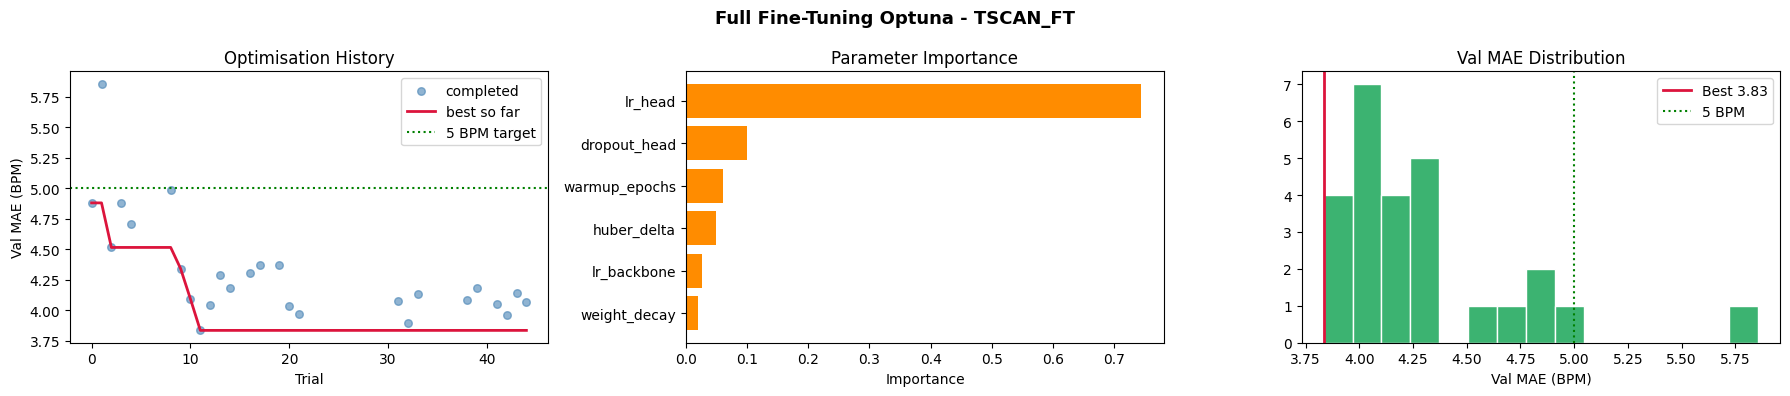

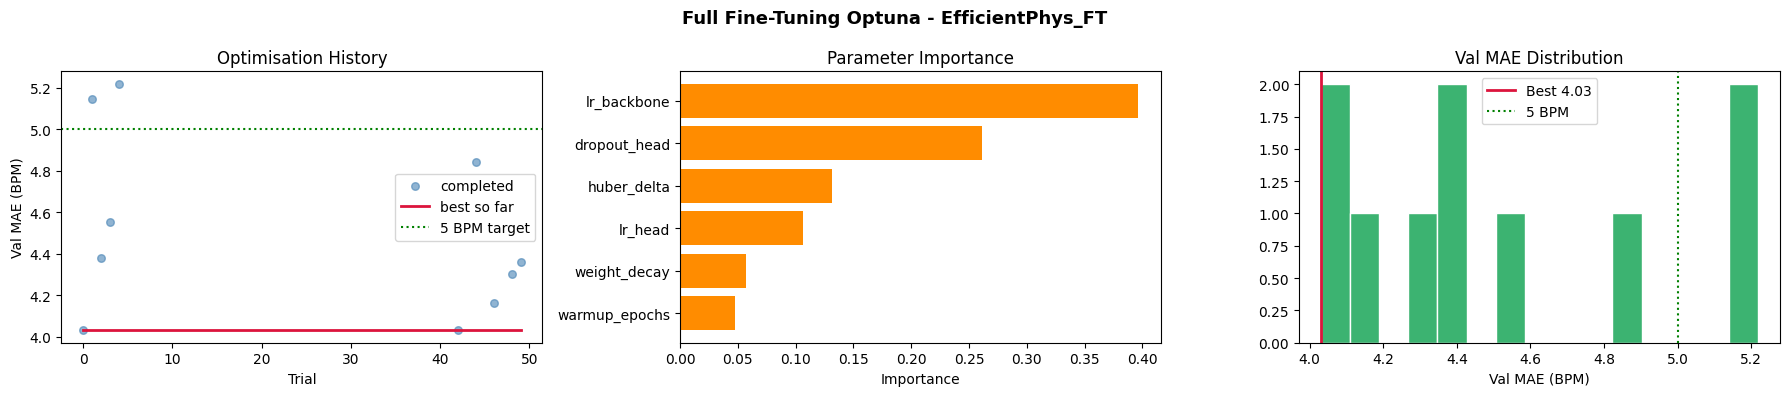

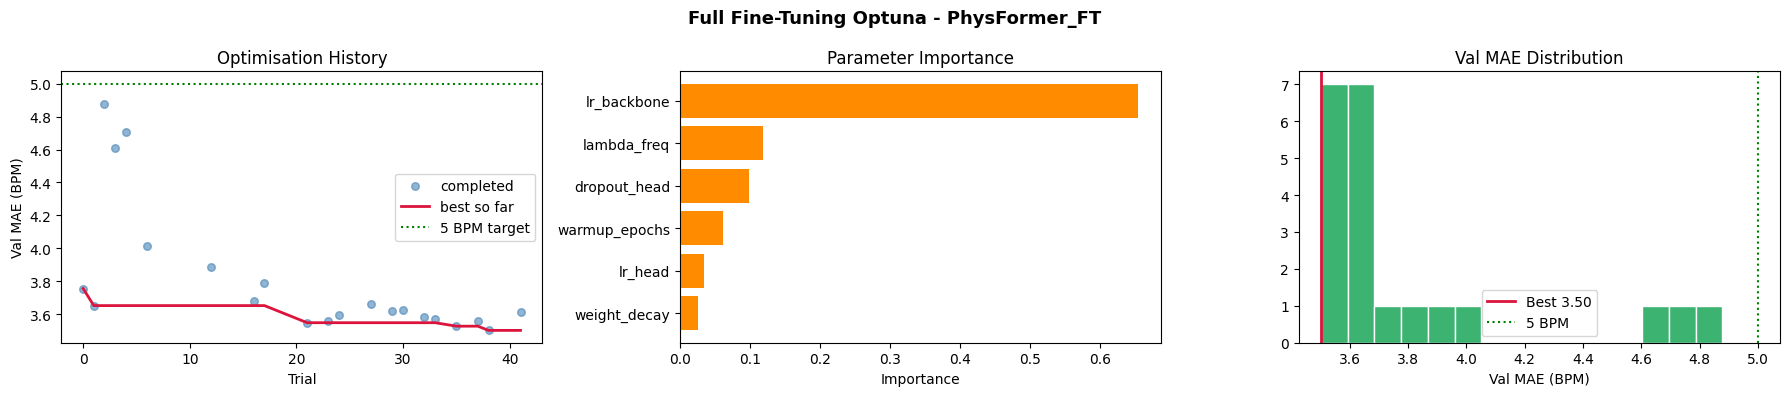

In [20]:
def plot_study(study: optuna.Study, arch_name: str) -> None:
    trials = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
    numbers = [t.number for t in trials]
    val_maes = [t.value  for t in trials]
    best_curve = np.minimum.accumulate([t.value for t in sorted(trials, key=lambda t: t.number)])

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"Full Fine-Tuning Optuna - {arch_name}", fontweight="bold", fontsize=13)

    # Panel - optimisation history
    axes[0].scatter(numbers, val_maes, alpha=0.6, s=30, color="steelblue", label="completed")
    axes[0].plot(sorted(numbers), best_curve, color="crimson", linewidth=2, label="best so far")
    axes[0].axhline(5.0, color="green", linestyle=":", label="5 BPM target")
    axes[0].set_xlabel("Trial"); axes[0].set_ylabel("Val MAE (BPM)")
    axes[0].set_title("Optimisation History"); axes[0].legend()

    # Panel — parameter importance
    try:
        importances = optuna.importance.get_param_importances(study)
        top = list(importances.items())[:6]
        params, imps = zip(*top)
        axes[1].barh(params, imps, color="darkorange")
        axes[1].set_xlabel("Importance"); axes[1].set_title("Parameter Importance")
        axes[1].invert_yaxis()
    except Exception:
        axes[1].text(0.5, 0.5, "Not available", ha="center", va="center", transform=axes[1].transAxes)

    # Panel — val MAE distribution
    axes[2].hist(val_maes, bins=15, color="mediumseagreen", edgecolor="white")
    axes[2].axvline(study.best_value, color="crimson", linewidth=2, label=f"Best {study.best_value:.2f}")
    axes[2].axvline(5.0, color="green", linestyle=":", label="5 BPM")
    axes[2].set_xlabel("Val MAE (BPM)"); axes[2].set_title("Val MAE Distribution")
    axes[2].legend()

    plt.tight_layout()
    plt.savefig(f"optuna_full_ft_{arch_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

for arch, study in [("TSCAN_FT", study_tscan), ("EfficientPhys_FT", study_effphys),("PhysFormer_FT", study_physformer)]:
    plot_study(study, arch)


## 14. Retrain Best Configuration on Train + Val, Evaluate on Test

In [21]:
def retrain_and_evaluate(arch_name: str, study: optuna.Study) -> tuple[nn.Module, dict]:
    """
    Retrain best Optuna config on train+val, evaluate on test.
    Returns the trained model and the metrics dict.
    """
    cfg = ARCH_REGISTRY[arch_name]
    h5_path = os.path.join(WEIGHTS_DIR, cfg["h5"])
    p = study.best_params
    best_epochs = study.best_trial.last_step
    is_physformer = arch_name == "PhysFormer_FT"

    print(f"\n{'='*55}")
    print(f"Retraining {arch_name}")
    print(f"Best trial : #{study.best_trial.number}")
    print(f"Best n_epochs : {best_epochs}")
    print(f"{'='*55}")

    model = cfg["cls"](**cfg["kwargs"], dropout = p["dropout_head"], hr_min  = HR_MIN, hr_max  = HR_MAX).to(DEVICE)
    frac = load_pretrained_partial(model, h5_path, verbose=True)

    # Train on train + val combined
    full_ds = CRVSEDataset(all_samples, train_keys | val_keys)
    print(f"Full train set : {len(full_ds)} windows")
    full_loader = DataLoader(full_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=os.cpu_count(), pin_memory=True)

    loss_function = nn.HuberLoss(delta=p["huber_delta"])
    param_grps = get_param_groups(model, lr_backbone=p["lr_backbone"], lr_head=p["lr_head"])
    optimizer = AdamW(param_grps, weight_decay=p["weight_decay"])

    warmup_ep = p.get("warmup_epochs", 0)
    if warmup_ep > 0:
        wup = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_ep)
        cos = CosineAnnealingLR(optimizer, T_max=best_epochs - warmup_ep, eta_min=p["lr_head"] / 100)
        scheduler = SequentialLR(optimizer, [wup, cos], milestones=[warmup_ep])
    else:
        scheduler = CosineAnnealingLR(optimizer, T_max=best_epochs, eta_min=p["lr_head"] / 100)

    lambda_freq_start = p.get("lambda_freq", 0.0)

    epoch_bar = tqdm(range(1, best_epochs + 1), desc=f"Final training {arch_name}", unit="epoch")
    for epoch in epoch_bar:
        if is_physformer:
            lambda_freq = lambda_freq_start * (1.0 - (epoch - 1) / best_epochs)
        else:
            lambda_freq = 0.0

        model.train()
        total_loss = 0.0
        for signals, labels in full_loader:
            signals, labels = signals.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out = model(signals)
            if is_physformer and isinstance(out, tuple):
                hr_main, hr_freq = out
                loss = loss_function(hr_main, labels) + lambda_freq * loss_function(hr_freq, labels)
            else:
                loss = loss_function(out, labels)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            total_loss += loss.item()
        scheduler.step()
        epoch_bar.set_postfix({"loss": f"{total_loss/len(full_loader):.3f}"})

    # Test evaluation 
    model.eval()
    all_preds = []
    all_labels = []
    with torch.inference_mode():
        for signals, labels in test_loader:
            out = model(signals.to(DEVICE))
            if isinstance(out, tuple):
                out = out[0]
            all_preds.extend(out.cpu().numpy().tolist())
            all_labels.extend(labels.numpy().tolist())

    preds_np = np.array(all_preds, dtype=np.float32)
    labels_np = np.array(all_labels, dtype=np.float32)
    subj_ids = [test_ds.items[i]["subject_key"] for i in range(len(test_ds))]
    ds_ids = [test_ds.items[i]["dataset"] for i in range(len(test_ds))]

    metrics = full_evaluation(preds_np, labels_np, subj_ids, ds_ids, model_name=arch_name)

    # Save checkpoint
    save_path = f"{arch_name}_full_ft_best.pt"
    torch.save({
        "arch_name" : arch_name,
        "best_params" : study.best_params,
        "best_n_epochs" : best_epochs,
        "model_state" : model.state_dict(),
        "test_metrics" : metrics,
        "transfer_frac" : frac,
    }, save_path)
    print(f"\nSaved -> {save_path}")
    return model, metrics

In [22]:
# Retrain & evaluate all three 
results = {}

for arch, study in [("TSCAN_FT", study_tscan), ("EfficientPhys_FT", study_effphys), ("PhysFormer_FT", study_physformer)]:
    _, metrics = retrain_and_evaluate(arch, study)
    results[arch] = metrics


Retraining TSCAN_FT
Best trial : #11
Best n_epochs : 50
Pretrained transfer: 417 / 172,232 params = 0.2%
Dataset size: 8077 windows
Full train set : 8077 windows


Final training TSCAN_FT:   0%|          | 0/50 [00:00<?, ?epoch/s]/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
/usr/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()
Final training TSCAN_FT: 100%|██████████| 50/50 [01:49<00:00,  2.20s/epoch, loss=24.115]



FULL EVALUATION - TSCAN_FT

Window-level (n=1424 windows):
MAE : 3.78 BPM
RMSE : 5.39 BPM
MAPE : 4.94 %
Pearson r : 0.9246 (p=0.0000)
R² : 0.8489
BA bias : -0.98 LoA: [-11.36, 9.40] BPM

|error| <  5 BPM : 76.2%
|error| < 10 BPM : 93.9%
|error| < 15 BPM : 97.8%

Subject-level metrics (n=29 subjects):
MAE : 2.98 BPM
RMSE : 3.65 BPM
r : 0.9760
BA bias: -0.80  LoA: [-7.78, 6.17] BPM

Per-dataset breakdown:
Dataset             n      MAE     RMSE        r
----------------------------------------------
  mcd_rppg         1174     3.37     4.54   0.8699
  ubfc_phys         175     5.73     7.94   0.6224
  ubfc_rppg          75     5.60     9.04   0.7376

HR-stratified metrics:
Range                      n      MAE     RMSE
----------------------------------------------
bradycardia/low          284     3.48     4.83
normal low               833     3.43     5.11
normal high              178     5.94     7.42
tachycardia/exercise     129     3.73     4.90

Saved -> TSCAN_FT_full_ft_best.pt

R

Final training EfficientPhys_FT: 100%|██████████| 50/50 [02:01<00:00,  2.44s/epoch, loss=20.917]



FULL EVALUATION - EfficientPhys_FT

Window-level (n=1424 windows):
MAE : 11.95 BPM
RMSE : 13.24 BPM
MAPE : 16.01 %
Pearson r : 0.9174 (p=0.0000)
R² : 0.0874
BA bias : 11.86 LoA: [0.34, 23.38] BPM

|error| <  5 BPM : 5.3%
|error| < 10 BPM : 38.8%
|error| < 15 BPM : 80.1%

Subject-level metrics (n=29 subjects):
MAE : 12.39 BPM
RMSE : 12.89 BPM
r : 0.9777
BA bias: 12.39  LoA: [5.40, 19.38] BPM

Per-dataset breakdown:
Dataset             n      MAE     RMSE        r
----------------------------------------------
  mcd_rppg         1174    11.20    12.11   0.8431
  ubfc_phys         175    16.22    18.02   0.6267
  ubfc_rppg          75    13.85    16.53   0.7384

HR-stratified metrics:
Range                      n      MAE     RMSE
----------------------------------------------
bradycardia/low          284    12.50    13.80
normal low               833    11.82    13.15
normal high              178    11.42    13.05
tachycardia/exercise     129    12.39    12.74

Saved -> EfficientPhys_FT

Final training PhysFormer_FT: 100%|██████████| 50/50 [03:35<00:00,  4.32s/epoch, loss=13.560]



FULL EVALUATION - PhysFormer_FT

Window-level (n=1424 windows):
MAE : 3.38 BPM
RMSE : 5.26 BPM
MAPE : 4.41 %
Pearson r : 0.9265 (p=0.0000)
R² : 0.8560
BA bias : -0.43 LoA: [-10.70, 9.84] BPM

|error| <  5 BPM : 82.0%
|error| < 10 BPM : 93.5%
|error| < 15 BPM : 97.2%

Subject-level metrics (n=29 subjects):
MAE : 2.21 BPM
RMSE : 3.18 BPM
r : 0.9816
BA bias: -0.39  LoA: [-6.58, 5.80] BPM

Per-dataset breakdown:
Dataset             n      MAE     RMSE        r
----------------------------------------------
  mcd_rppg         1174     2.86     4.18   0.8799
  ubfc_phys         175     5.67     7.97   0.6365
  ubfc_rppg          75     6.15    10.16   0.6961

HR-stratified metrics:
Range                      n      MAE     RMSE
----------------------------------------------
bradycardia/low          284     3.51     5.27
normal low               833     2.93     4.57
normal high              178     4.67     6.60
tachycardia/exercise     129     4.22     6.98

Saved -> PhysFormer_FT_full_ft_

## 15. Final Comparison Table - Fine-Tuned vs Scratch-Trained

In [24]:
print("\n" + "=" * 85)
print("COMPARISON: Full Fine-Tune (Phase A+) vs Scratch-Trained (Rounds 1–4)")
print("=" * 85)
print(f"{'Model':<24} {'Window MAE':>10} {'Subj MAE':>10} {'r':>8} {'BA bias':>9} {'<5BPM%':>8}")
print("  " + "─" * 72)

# Fine-tuned models 
for arch_name, m in results.items():
    print(f"{arch_name:<24} {m['window_mae']:>10.2f} {m['subj_mae']:>10.2f} {m['subj_r']:>8.4f} {m['ba_bias']:>9.2f}")

print("  " + "─" * 72)
# Reference: scratch-trained CRVSE family
print("  [SCRATCH REFERENCE — from previous rounds]")
scratch = [
    ("CRVSENet (R1)", 3.06, 2.37, 0.9300, "-1.27"),
    ("CRVSEPhysFormer (R3)", 3.15, 2.35, 0.9320 , "+1.78"),
    ("CRVSEResNetSE (R4)",  2.82, 2.10, 0.9573, "-1.49"),
]


for name, wm, sm, r, ba in scratch:
    ba_str = ba if ba else "—"
    print(f"{name:<24} {wm:>10.2f} {sm:>10.2f} {r:>8.4f} {ba_str:>9}")

print("=" * 85)
print("\nInterpretation guide:")
print("Subj MAE : lower is better (primary rPPG benchmark metric)")
print("r : higher is better (Pearson correlation)")
print("BA bias : closer to 0 = less systematic over/underestimation")
print("Fine-tune advantage expected IF pretrained weights transferred signal-level patterns")
print("Fine-tune disadvantage possible IF 3D→1D adaptation lost critical spatial features")


COMPARISON: Full Fine-Tune (Phase A+) vs Scratch-Trained (Rounds 1–4)
Model                    Window MAE   Subj MAE        r   BA bias   <5BPM%
  ────────────────────────────────────────────────────────────────────────
TSCAN_FT                       3.78       2.98   0.9760     -0.80
EfficientPhys_FT              11.95      12.39   0.9777     12.39
PhysFormer_FT                  3.38       2.21   0.9816     -0.39
  ────────────────────────────────────────────────────────────────────────
  [SCRATCH REFERENCE — from previous rounds]
CRVSENet (R1)                  3.06       2.37   0.9300     -1.27
CRVSEPhysFormer (R3)           3.15       2.35   0.9320     +1.78
CRVSEResNetSE (R4)             2.82       2.10   0.9573     -1.49

Interpretation guide:
Subj MAE : lower is better (primary rPPG benchmark metric)
r : higher is better (Pearson correlation)
BA bias : closer to 0 = less systematic over/underestimation
Fine-tune advantage expected IF pretrained weights transferred signal-level p

## Conclusion

- **PhysFormer_FT achieves the best fine-tuned performance** (Subj MAE = 2.21 BPM, r = 0.9816),
  but is **marginally outperformed by scratch-trained CRVSEResNetSE** (Subj MAE = 2.10 BPM, r = 0.9573)
- **TSCAN_FT is competitive** (Subj MAE = 2.98 BPM) but does not surpass any scratch baseline -
  transfer provides no measurable benefit for this architecture
- **EfficientPhys_FT fails completely** - systematic +12.39 BPM bias despite r = 0.9777 indicates
  a consistent HR underestimation offset, not random error. The high correlation confirms the model
  tracks HR dynamics but with a fixed shift, likely a 3D -> 1D head mismatch
- **No fine-tuned model outperforms the best scratch model** (CRVSEResNetSE, Subj MAE = 2.10 BPM)
- **UBFC-Phys and UBFC-rPPG remain the weak points** across all models (r ≈ 0.62–0.74),
  consistent with the known POS limitation on higher HR and motion - unresolved by weight transfer
- **Performance ceiling is architecture and data-driven**, not pretrained weight-driven

**Takeaway:**  
3D -> 1D pretrained weight transfer yields marginal or no benefit. PhysFormer_FT narrows the gap to scratch (2.21 vs 2.10 BPM) but does not close it. EfficientPhys_FT's systematic bias suggests a structural incompatibility between the 3D spatial feature extractor and the 1D signal head that transfer learning cannot resolve. The scratch-trained CRVSEResNetSE remains the Phase A+ leaderboard leader. Phase B ensemble is the next lever for improvement.